# 第48篇 | 特征工程：数据预处理与特征选择

> 这是「数据分析从入门到精通」系列的第 48 篇。Scikit-learn 的工作流跑通了，这篇来聊机器学习里最"值钱"的一步——特征工程。"数据和特征决定了机器学习的上限，模型只是逼近这个上限"，这篇带你把原始数据炼成好特征。

嗨，我是小荷～ 今天聊一个机器学习里最"接地气"的话题：**特征工程**。有句行话叫"数据和特征决定了机器学习的上限，模型只是逼近这个上限"，可见它的重要性！

---

## 一、什么是特征工程？

**定义**：将原始数据转换为更能代表预测模型的特征的过程。

**为什么重要？**
- 好的特征让简单模型也能有好效果
- 垃圾特征让复杂模型也无能为力
- 特征工程往往比调参更花时间和精力


**核心步骤：**

特征清洗、特征转换，特征构造和特征选择

1. 特征清洗：在处理特征前，必须先保证数据质量。
   - 缺失值处理：使用均值、中位数、众数填补，或使用算法（如KNN）插补，或直接删除缺失比例过高的行/列。
   - 异常值处理：通过箱线图、3σ 法则识别并处理极端异常数据。
   - 去重：删除重复样本以防止模型产生偏差。

2. 特征转换：将数据调整为算法最易识别和处理的数值格式。
   - 数值缩放 (Scaling)
        - 标准化 (Standardization)：使数据符合标准正态分布，均值为 0，方差为 1。
        - 归一化 (Normalization)：将数据缩放到特定范围（如 \([0, 1]\)），常用于距离计算。
   - 分布转换：对于倾斜的数据，使用对数变换 (Log) 或 Box-Cox 变换使其更接近正态分布。
   - 编码 (Encoding)：
       - 独热编码 (One-Hot Encoding)：将类别变量（如颜色：红、蓝、绿）转换为二进制特征。
       - 标签编码 (Label Encoding)：将类别映射为整数。

3. 特征构造 (Feature Construction)结合业务逻辑（领域知识）从现有特征中衍生出新特征，增强模型的表达能力。
   - 四则运算：如将“总价”和“面积”组合出“单价”。
   - 统计聚合：计算滑动窗口内的均值、最大值、最小值等（常用于时序数据）。
   - 时间特征提取：从“日期”中提取出“是否节假日”、“星期几”等。
   - 分箱：将连续年龄分为"青年"、"中年"、"老年"等区间，将连续数据离散化。
    
4. 特征选择 (Feature Selection)从提取的大量特征中，挑选出对预测目标最有用、相关性最强的特征子集，以降低计算成本并防止过拟合。
   - 过滤法 (Filter)：基于统计指标（如相关系数卡方检验、方差阈值）评估特征。独立于任何模型。
   - 包裹法 (Wrapper)：通过逐步选择/剔除特征（如递归特征消除 RFE）来寻找最优组合。效果较好，但计算成本高。
   - 嵌入法 (Embedded)：使用带有惩罚项的模型（如 Lasso 回归、随机森林的特征重要性）在训练过程中自动筛选特征。
  

---

## 二、数据清洗

### 2.1 缺失值处理

缺失值处理是数据清洗的核心环节：


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, 
                                    LabelEncoder, OneHotEncoder)
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcdefaults()
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [5]:
# 创建示例数据
np.random.seed(42)
df = pd.DataFrame({
    '年龄': [25, 30, np.nan, 35, 40, np.nan, 28, 45],
    '收入': [50000, 60000, 55000, np.nan, 80000, 70000, np.nan, 90000],
    '城市': ['北京', '上海', '北京', '广州', np.nan, '上海', '北京', '广州'],
    '购买': [1, 0, 1, 0, 1, 1, 0, 1]
})

print("原始数据:")
print(df)
print(f"\n缺失值统计:")
print(df.isnull().sum())

# 缺失值处理策略
print("\n" + "-"*40)
print("缺失值处理策略:")

# 数值型：用中位数填充
df['年龄_填充'] = df['年龄'].fillna(df['年龄'].median())
df['收入_填充'] = df['收入'].fillna(df['收入'].median())

# 分类型：用众数填充
df['城市_填充'] = df['城市'].fillna(df['城市'].mode()[0])

print("处理后:")
print(df[['年龄_填充', '收入_填充', '城市_填充']])


原始数据:
     年龄       收入   城市  购买
0  25.0  50000.0   北京   1
1  30.0  60000.0   上海   0
2   NaN  55000.0   北京   1
3  35.0      NaN   广州   0
4  40.0  80000.0  NaN   1
5   NaN  70000.0   上海   1
6  28.0      NaN   北京   0
7  45.0  90000.0   广州   1

缺失值统计:
年龄    2
收入    2
城市    1
购买    0
dtype: int64

----------------------------------------
缺失值处理策略:
处理后:
   年龄_填充    收入_填充 城市_填充
0   25.0  50000.0    北京
1   30.0  60000.0    上海
2   32.5  55000.0    北京
3   35.0  65000.0    广州
4   40.0  80000.0    北京
5   32.5  70000.0    上海
6   28.0  65000.0    北京
7   45.0  90000.0    广州


### 2.2 异常值检测与处理

异常值会拉偏模型，得处理掉：


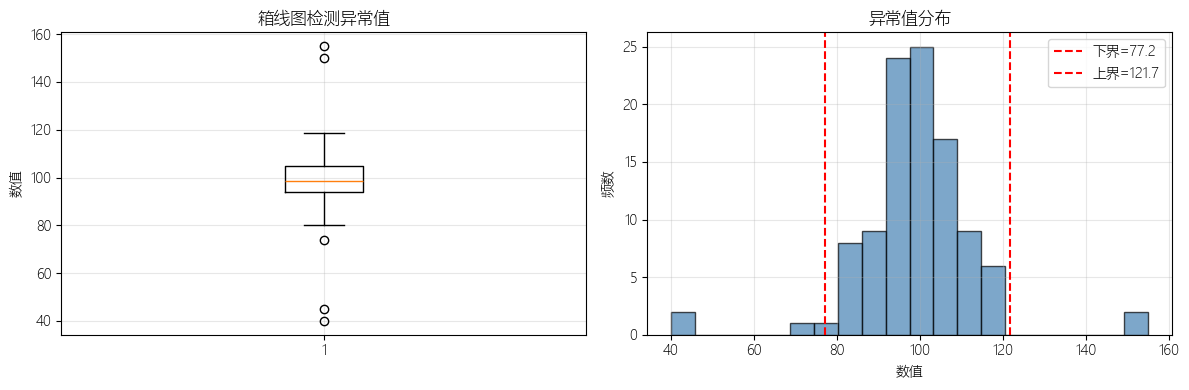


检测到 5 个异常值: [ 73.80254896 150.         155.          45.          40.        ]
IQR方法边界: [77.2, 121.7]


In [6]:
# 生成含异常值的数据
np.random.seed(42)
data = np.concatenate([
    np.random.normal(100, 10, 100),  # 正常数据
    [150, 155, 45, 40]  # 异常值
])

# 箱线图法检测异常值
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data < lower_bound) | (data > upper_bound)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 箱线图
axes[0].boxplot(data, vert=True)
axes[0].set_ylabel('数值')
axes[0].set_title('箱线图检测异常值')
axes[0].grid(True, alpha=0.3)

# 直方图
axes[1].hist(data, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
axes[1].axvline(x=lower_bound, color='red', linestyle='--', label=f'下界={lower_bound:.1f}')
axes[1].axvline(x=upper_bound, color='red', linestyle='--', label=f'上界={upper_bound:.1f}')
axes[1].set_xlabel('数值')
axes[1].set_ylabel('频数')
axes[1].set_title('异常值分布')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n检测到 {len(outliers)} 个异常值: {outliers}")
print(f"IQR方法边界: [{lower_bound:.1f}, {upper_bound:.1f}]")


---

## 三、特征变换

### 3.1 标准化 vs 归一化

来对比一下两者的差异：


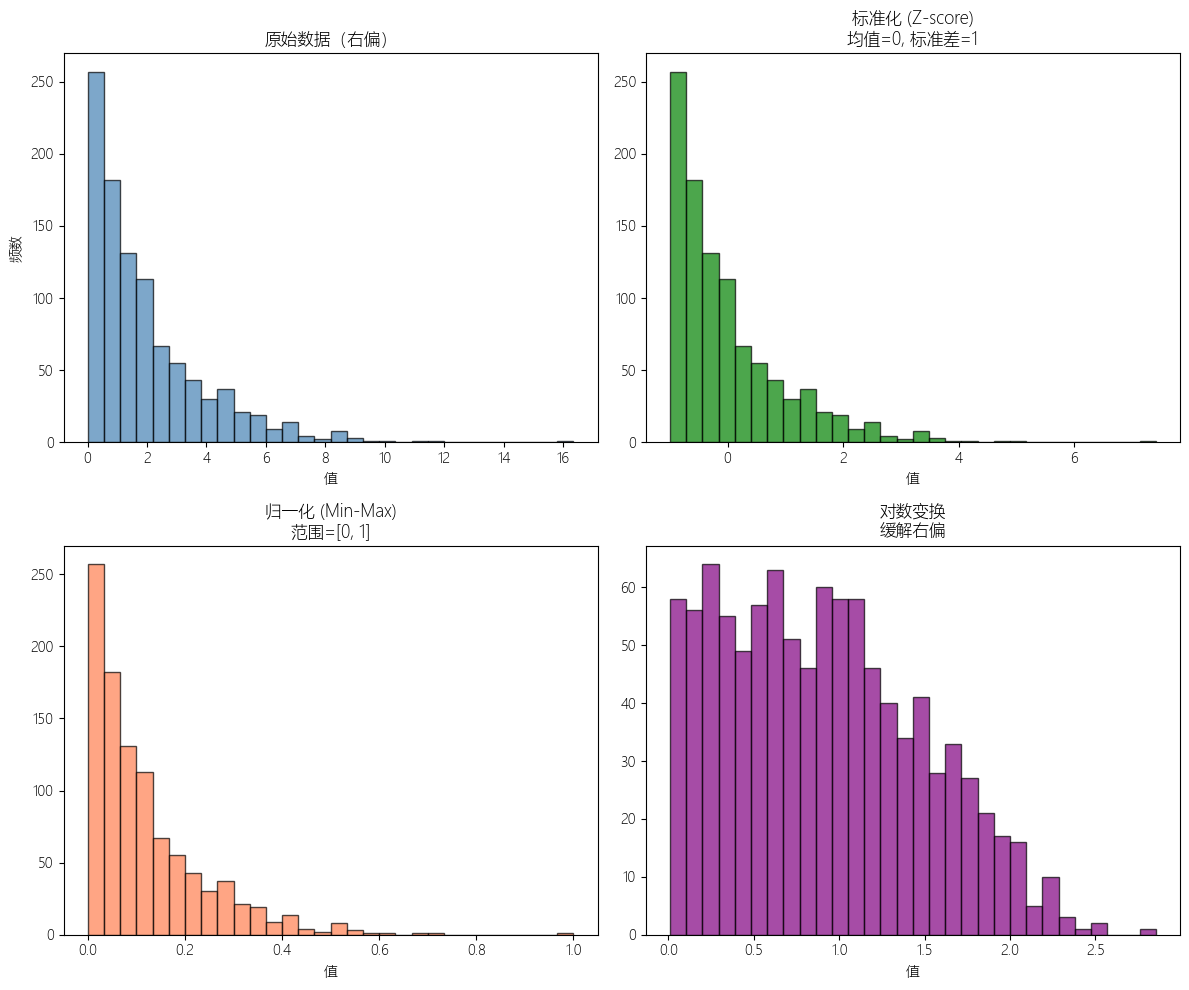


原始数据: 均值=1.95, 标准差=1.94
标准化后: 均值=-0.0000, 标准差=1.0000
归一化后: 最小值=0.0000, 最大值=1.0000


In [16]:
# 生成偏态数据
np.random.seed(42)
skewed_data = np.random.exponential(2, 1000)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 原始数据
axes[0, 0].hist(skewed_data, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].set_title('原始数据（右偏）')
axes[0, 0].set_xlabel('值')
axes[0, 0].set_ylabel('频数')

# 标准化 (Z-score)
scaler_std = StandardScaler()
data_standardized = scaler_std.fit_transform(skewed_data.reshape(-1, 1)).flatten()
axes[0, 1].hist(data_standardized, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_title('标准化 (Z-score)\n均值=0, 标准差=1')
axes[0, 1].set_xlabel('值')

# 归一化 (Min-Max)
scaler_minmax = MinMaxScaler()
data_normalized = scaler_minmax.fit_transform(skewed_data.reshape(-1, 1)).flatten()
axes[1, 0].hist(data_normalized, bins=30, alpha=0.7, color='coral', edgecolor='black')
axes[1, 0].set_title('归一化 (Min-Max)\n范围=[0, 1]')
axes[1, 0].set_xlabel('值')

# 对数变换
data_log = np.log1p(skewed_data)
axes[1, 1].hist(data_log, bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[1, 1].set_title('对数变换\n缓解右偏')
axes[1, 1].set_xlabel('值')

plt.tight_layout()
plt.show()

print(f"\n原始数据: 均值={skewed_data.mean():.2f}, 标准差={skewed_data.std():.2f}")
print(f"标准化后: 均值={data_standardized.mean():.4f}, 标准差={data_standardized.std():.4f}")
print(f"归一化后: 最小值={data_normalized.min():.4f}, 最大值={data_normalized.max():.4f}")


**什么时候用什么？**

| 方法 | 公式 | 适用场景 |
|------|------|----------|
| **标准化** | $(x - \mu) / \sigma$ | 数据近似正态分布、有异常值、需要比较不同量纲 |
| **归一化** | $(x - min) / (max - min)$ | 需要固定范围、神经网络输入、图像像素 |
| **对数变换** | $\log(x+1)$ | 右偏数据、金额类特征 |

---

## 四、特征编码

### 4.1 标签编码（Label Encoding）

类别变量必须编码成数字，模型才能处理：


In [21]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

# ========== 1. 构造数据：城市和房价【完全没关系】 ==========
# 四个城市：无序、无大小关系
cities = ["北京", "上海", "广州", "深圳"]

# 随机生成房价，确保【城市和房价无关】
np.random.seed(42)
y = np.random.randint(480, 520, size=100)  # 房价随机
X = np.random.choice(cities, size=100)      # 城市随机

# ========== 2. 标签编码 ==========
le = LabelEncoder()
X_encoded = le.fit_transform(X).reshape(-1, 1)

print("城市编码：")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# ========== 3. 训练线性模型 ==========
model = LinearRegression()
model.fit(X_encoded, y)

# ========== 4. 预测：看模型是否学到顺序 ==========
test = [[0], [1], [2], [3]]
preds = model.predict(test)

print("\n【模型预测结果】")
for city, p in zip(le.classes_, preds):
    print(f"{city} 预测房价 = {p:.2f}")

城市编码：
{np.str_('上海'): np.int64(0), np.str_('北京'): np.int64(1), np.str_('广州'): np.int64(2), np.str_('深圳'): np.int64(3)}

【模型预测结果】
上海 预测房价 = 494.59
北京 预测房价 = 497.33
广州 预测房价 = 500.08
深圳 预测房价 = 502.83


### 4.2 独热编码（One-Hot Encoding）

类别变量必须编码成数字，模型才能处理：


标签编码:
原始: ['北京', '上海', '广州', '北京', '深圳', '上海', '北京']
编码: [1 0 2 1 3 0 1]
类别映射: {np.str_('上海'): np.int64(0), np.str_('北京'): np.int64(1), np.str_('广州'): np.int64(2), np.str_('深圳'): np.int64(3)}

独热编码:
   城市_上海  城市_北京  城市_广州  城市_深圳
0  False   True  False  False
1   True  False  False  False
2  False  False   True  False
3  False   True  False  False
4  False  False  False   True
5   True  False  False  False
6  False   True  False  False


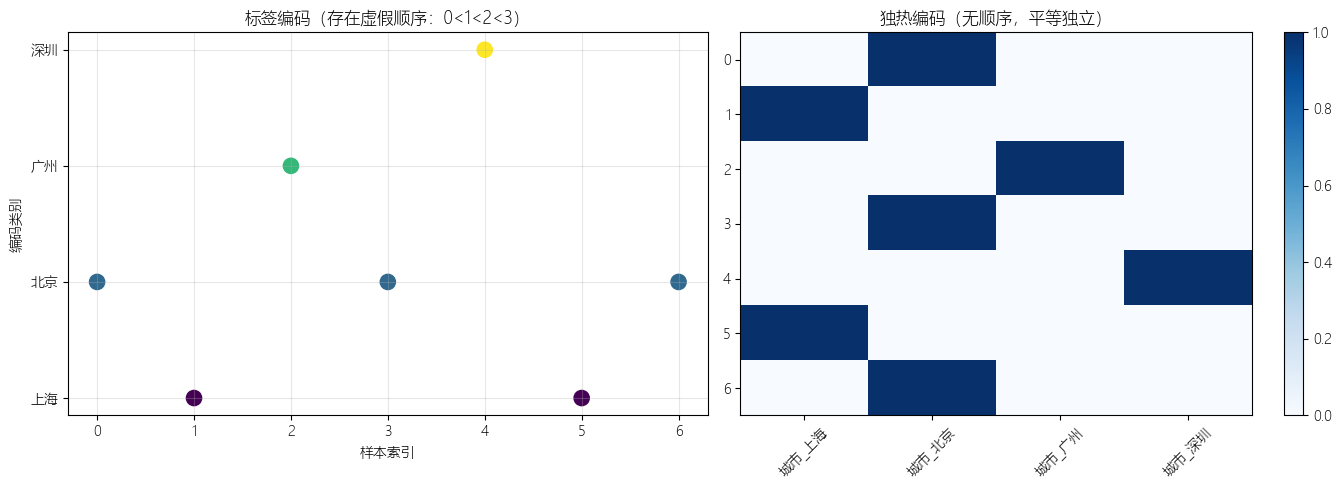

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# 原始数据
cities = ['北京', '上海', '广州', '北京', '深圳', '上海', '北京']

# ====================== 标签编码 ======================
le = LabelEncoder()
cities_encoded = le.fit_transform(cities)

print("标签编码:")
print(f"原始: {cities}")
print(f"编码: {cities_encoded}")
print(f"类别映射: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ====================== 独热编码（正确方式） ======================
cities_df = pd.DataFrame({'城市': cities})
cities_onehot = pd.get_dummies(cities_df['城市'], prefix='城市')

print("\n独热编码:")
print(cities_onehot)

# ====================== 可视化对比（已修复报错） ======================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：标签编码（修复版）
x_pos = np.arange(len(cities_encoded))  # 关键修复：和编码长度一致
axes[0].scatter(x_pos, cities_encoded, c=cities_encoded, cmap='viridis', s=120)
axes[0].set_yticks(range(len(le.classes_)))
axes[0].set_yticklabels(le.classes_)
axes[0].set_xlabel('样本索引')
axes[0].set_ylabel('编码类别')
axes[0].set_title('标签编码（存在虚假顺序：0<1<2<3）')
axes[0].grid(True, alpha=0.3)

# 右图：独热编码
im = axes[1].imshow(cities_onehot.values, cmap='Blues', aspect='auto')
axes[1].set_xticks(np.arange(len(cities_onehot.columns)))
axes[1].set_xticklabels(cities_onehot.columns, rotation=45)
axes[1].set_title('独热编码（无顺序，平等独立）')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

---

## 五、特征选择

### 5.1 过滤法（Filter）

Filter，来看具体怎么操作：


过滤法特征选择 (F检验):
----------------------------------------
  特征        F得分    选中
特征14 695.821411  True
特征19 133.909980  True
特征11 109.856998  True
特征12 109.604838  True
特征10  97.751043  True
 特征1  57.509070  True
特征15  48.949820  True
 特征6  16.653366  True
 特征9  13.145589  True
 特征3   2.950222  True
 特征2   2.404970 False
特征18   1.664318 False
 特征7   1.540624 False
 特征8   1.521447 False
特征16   0.732411 False
特征17   0.548682 False
特征20   0.476436 False
特征13   0.348943 False
 特征4   0.187842 False
 特征5   0.077791 False


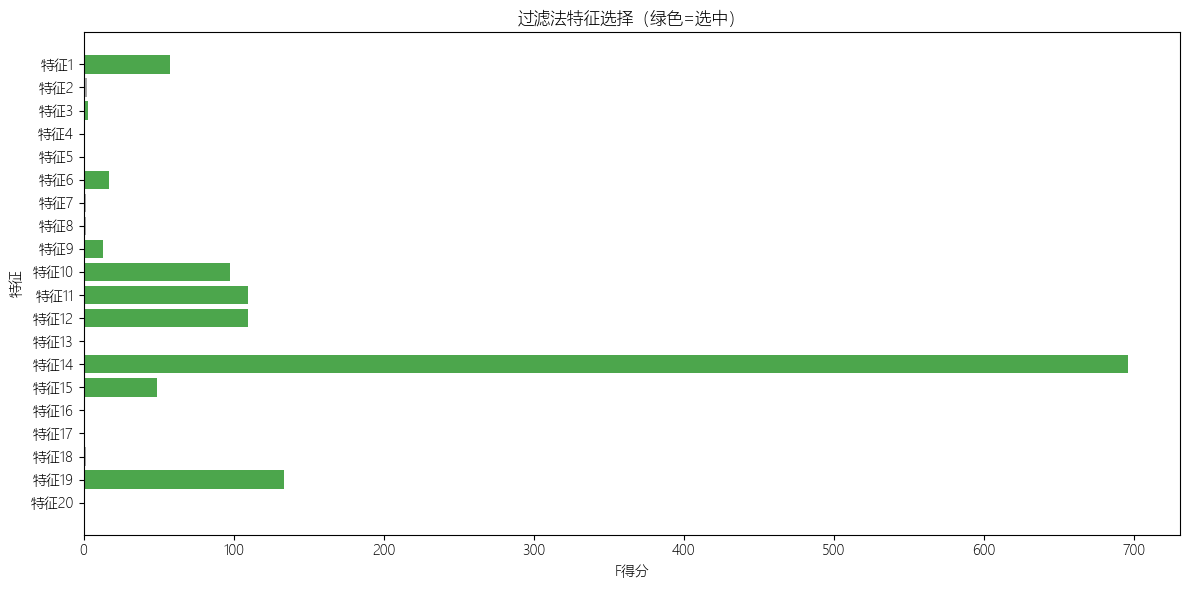

In [23]:
# 生成分类数据
X, y = make_classification(n_samples=1000, n_features=20, n_informative=5,
                           n_redundant=5, n_repeated=0, n_classes=2,
                           random_state=42)
feature_names = [f'特征{i+1}' for i in range(20)]

# 方差选择 + F检验
selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X, y)

# 查看得分
scores = selector.scores_
selected_mask = selector.get_support()

print("过滤法特征选择 (F检验):")
print("-" * 40)
feature_scores = pd.DataFrame({
    '特征': feature_names,
    'F得分': scores,
    '选中': selected_mask
}).sort_values('F得分', ascending=False)

print(feature_scores.to_string(index=False))

# 可视化
plt.figure(figsize=(12, 6))
colors = ['green' if s else 'gray' for s in selected_mask]
plt.barh(feature_names, scores, color=colors, alpha=0.7)
plt.xlabel('F得分')
plt.ylabel('特征')
plt.title('过滤法特征选择（绿色=选中）')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 5.2 包装法（Wrapper）

Wrapper，来看具体怎么操作：


In [24]:
# 递归特征消除 (RFE)
model = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=model, n_features_to_select=5)
X_rfe = rfe.fit_transform(X, y)

print("\n包装法特征选择 (RFE):")
print("-" * 40)
rfe_results = pd.DataFrame({
    '特征': feature_names,
    '选中': rfe.support_,
    '排名': rfe.ranking_
}).sort_values('排名')

print(rfe_results.to_string(index=False))
print(f"\n选中的特征: {[f for f, s in zip(feature_names, rfe.support_) if s]}")



包装法特征选择 (RFE):
----------------------------------------
  特征    选中  排名
 特征1  True   1
 特征6  True   1
特征14  True   1
特征10  True   1
特征19  True   1
特征12 False   2
特征18 False   3
 特征7 False   4
 特征2 False   5
 特征3 False   6
特征20 False   7
特征11 False   8
特征13 False   9
 特征5 False  10
 特征9 False  11
特征16 False  12
特征15 False  13
 特征8 False  14
 特征4 False  15
特征17 False  16

选中的特征: ['特征1', '特征6', '特征10', '特征14', '特征19']


### 5.3 嵌入法（Embedded）

Embedded，来看具体怎么操作：



嵌入法特征选择 (随机森林):
----------------------------------------
1. 特征14: 0.2283
2. 特征12: 0.1495
3. 特征9: 0.1165
4. 特征1: 0.0889
5. 特征6: 0.0686
6. 特征10: 0.0631
7. 特征11: 0.0538
8. 特征19: 0.0505
9. 特征16: 0.0328
10. 特征15: 0.0317


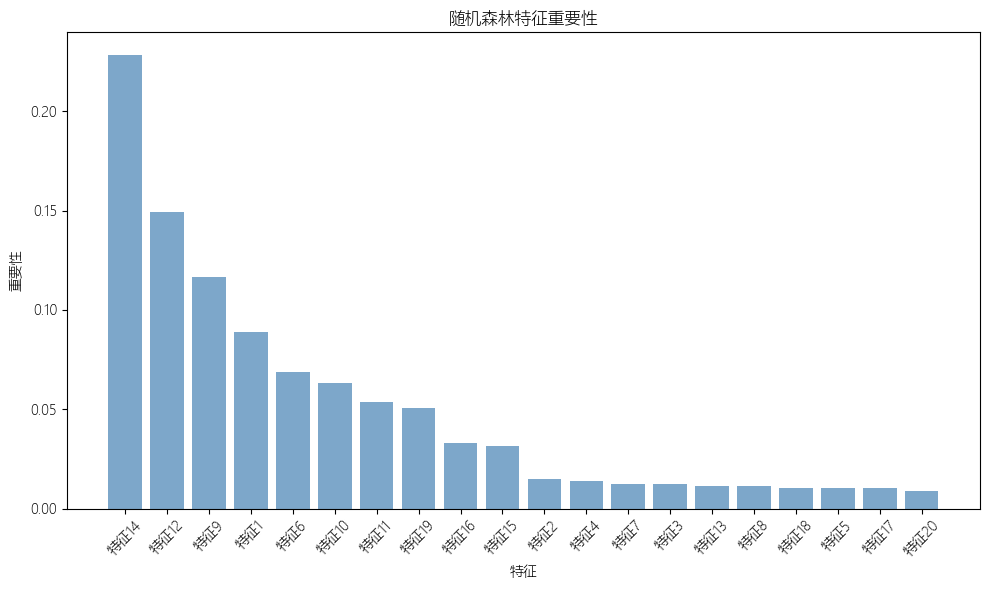

In [25]:
# 随机森林特征重要性
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

print("\n嵌入法特征选择 (随机森林):")
print("-" * 40)
for i in range(10):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# 可视化
plt.figure(figsize=(10, 6))
plt.bar(range(20), importances[indices], color='steelblue', alpha=0.7)
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=45)
plt.xlabel('特征')
plt.ylabel('重要性')
plt.title('随机森林特征重要性')
plt.tight_layout()
plt.show()

---

## 六、综合实战：完整特征工程流程

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


In [26]:
print("综合实战：房价数据特征工程")

# 模拟房价数据
np.random.seed(42)
n = 1000

housing_df = pd.DataFrame({
    '面积': np.random.lognormal(4.5, 0.5, n),  # 右偏分布
    '房龄': np.random.exponential(10, n),
    '卧室数': np.random.choice([1, 2, 3, 4, 5], n),
    '区域': np.random.choice(['朝阳', '海淀', '丰台', '昌平'], n),
    '朝向': np.random.choice(['南', '北', '东', '西'], n),
    '是否有电梯': np.random.choice([0, 1], n, p=[0.3, 0.7]),
    '距地铁距离': np.random.exponential(2, n),  # km，含缺失
    '价格': 0  # 待生成
})

# 添加缺失值
missing_idx = np.random.choice(n, size=50, replace=False)
housing_df.loc[missing_idx, '距地铁距离'] = np.nan

# 生成目标变量（价格）
housing_df['价格'] = (
    50 * housing_df['面积'] +
    -2 * housing_df['房龄'] ** 1.5 +
    30 * housing_df['卧室数'] +
    housing_df['区域'].map({'朝阳': 100, '海淀': 80, '丰台': 40, '昌平': 20}) +
    housing_df['朝向'].map({'南': 50, '东': 30, '西': 20, '北': 10}) +
    60 * housing_df['是否有电梯'] +
    -20 * housing_df['距地铁距离'].fillna(5) +
    np.random.normal(0, 50, n)
)

print("原始数据:")
print(housing_df.head())
print(f"\n缺失值:")
print(housing_df.isnull().sum())


综合实战：房价数据特征工程
原始数据:
           面积         房龄  卧室数  区域 朝向  是否有电梯     距地铁距离           价格
0  115.394544   1.833011    3  丰台  南      1  0.784927  5938.789282
1   84.004288   1.104488    4  昌平  南      1  2.234098  4354.398613
2  124.442563  10.117841    4  丰台  西      0  0.822766  6306.453199
3  192.773308  12.257949    1  昌平  南      0       NaN  9537.788312
4   80.071766   0.320957    2  海淀  西      1  0.660763  4255.600977

缺失值:
面积        0
房龄        0
卧室数       0
区域        0
朝向        0
是否有电梯     0
距地铁距离    50
价格        0
dtype: int64


数据看完了，开始动手清洗——这是特征工程的第一步：


In [27]:
# Step 1: 数据清洗
print("\n" + "-"*40)
print("Step 1: 数据清洗")

# 填充缺失值
housing_df['距地铁距离'].fillna(housing_df['距地铁距离'].median(), inplace=True)

# Step 2: 特征变换
print("Step 2: 特征变换")

# 对数变换处理右偏特征
housing_df['面积_log'] = np.log1p(housing_df['面积'])
housing_df['房龄_log'] = np.log1p(housing_df['房龄'])

# Step 3: 特征编码
print("Step 3: 特征编码")

# 独热编码
housing_encoded = pd.get_dummies(housing_df, columns=['区域', '朝向'], drop_first=True)

print("处理后特征:")
print(housing_encoded.columns.tolist())



----------------------------------------
Step 1: 数据清洗
Step 2: 特征变换
Step 3: 特征编码
处理后特征:
['面积', '房龄', '卧室数', '是否有电梯', '距地铁距离', '价格', '面积_log', '房龄_log', '区域_昌平', '区域_朝阳', '区域_海淀', '朝向_北', '朝向_南', '朝向_西']


编码完成后，进入关键环节——特征选择，挑出最有用的特征：



Step 4: 特征选择

特征重要性排名:
    特征      重要性
面积_log 0.881365
房龄_log 0.043803
 距地铁距离 0.034715
   卧室数 0.011736
  朝向_南 0.005821
 是否有电梯 0.004871
 区域_昌平 0.004793
 区域_朝阳 0.003614
 区域_海淀 0.003558
  朝向_西 0.003010
  朝向_北 0.002714


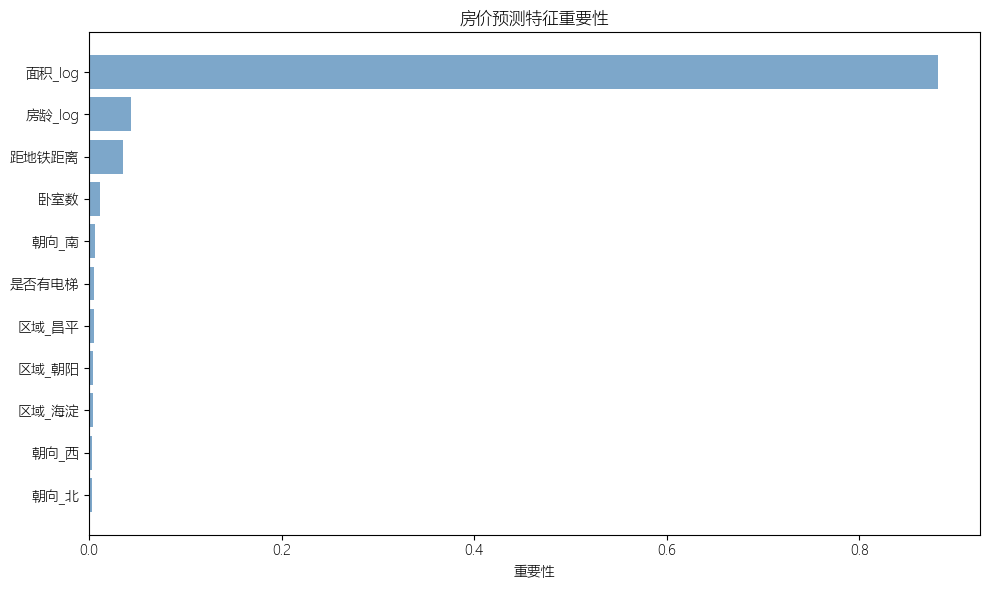

In [28]:
# Step 4: 特征选择
print("\nStep 4: 特征选择")

# 准备数据
X = housing_encoded.drop(['价格', '面积', '房龄'], axis=1)  # 用变换后的特征
y = housing_encoded['价格']

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 训练模型评估特征
rf_housing = RandomForestClassifier(n_estimators=100, random_state=42)
# 将价格转为分类问题（高/低）便于演示
y_binary = (y > y.median()).astype(int)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_binary, test_size=0.2, random_state=42)
rf_housing.fit(X_train_b, y_train_b)

# 特征重要性
importance_df = pd.DataFrame({
    '特征': X.columns,
    '重要性': rf_housing.feature_importances_
}).sort_values('重要性', ascending=False)

print("\n特征重要性排名:")
print(importance_df.to_string(index=False))

# 可视化
plt.figure(figsize=(10, 6))
plt.barh(importance_df['特征'], importance_df['重要性'], color='steelblue', alpha=0.7)
plt.xlabel('重要性')
plt.title('房价预测特征重要性')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---

## 七、小结

| 技术 | 用途 | 注意事项 |
|------|------|----------|
| **缺失值填充** | 处理不完整数据 | 数值用中位数，类别用众数 |
| **异常值处理** | 去除噪声 | IQR法、Z-score法 |
| **标准化** | 消除量纲影响 | 适用于近似正态分布 |
| **归一化** | 固定数值范围 | 适用于神经网络 |
| **对数变换** | 缓解右偏 | 注意0值处理 |
| **标签编码** | 类别转数值 | 仅适用于有序类别 |
| **独热编码** | 无序类别编码 | 注意维度爆炸 |
| **过滤法** | 快速筛选特征 | 独立于模型 |
| **包装法** | 模型驱动选择 | 计算成本高 |
| **嵌入法** | 训练时自动选择 | 如Lasso、树模型 |

---

## 八、课后练习

1. 对比标准化前后的模型效果差异
2. 尝试不同的缺失值填充策略（均值/中位数/众数），观察对模型的影响
3. 用RFE选择不同数量的特征，绘制"特征数-模型性能"曲线
4. 思考：为什么对数变换能缓解右偏分布？

练习1：标准化前后模型效果对比

原始数据准确率: 0.8500
标准化后准确率: 0.8367
提升: -0.0133

SVM原始数据准确率: 0.7500
SVM标准化后准确率: 0.9500
SVM提升: 0.2000


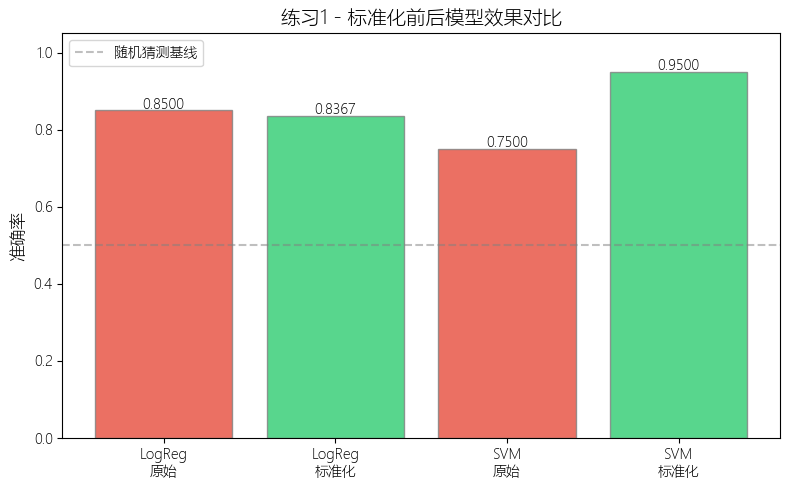

In [30]:
print("练习1：标准化前后模型效果对比")

# 生成含不同尺度特征的数据
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                           n_redundant=5, random_state=42)

# 故意放大某些特征的尺度，使数据尺度不均匀
X[:, 0:5] *= 100
X[:, 5:10] *= 0.01

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 不标准化训练
model_raw = LogisticRegression(max_iter=1000, random_state=42)
model_raw.fit(X_train, y_train)
acc_raw = model_raw.score(X_test, y_test)

# 标准化后训练
model_scaled = LogisticRegression(max_iter=1000, random_state=42)
model_scaled.fit(X_train_scaled, y_train)
acc_scaled = model_scaled.score(X_test_scaled, y_test)

print(f"\n原始数据准确率: {acc_raw:.4f}")
print(f"标准化后准确率: {acc_scaled:.4f}")
print(f"提升: {acc_scaled - acc_raw:.4f}")

# 用逻辑回归做对比（对特征尺度更敏感）
# 用SVM做进一步对比
from sklearn.svm import SVC

svm_raw = SVC(random_state=42)
svm_raw.fit(X_train, y_train)
acc_svm_raw = svm_raw.score(X_test, y_test)

svm_scaled = SVC(random_state=42)
svm_scaled.fit(X_train_scaled, y_train)
acc_svm_scaled = svm_scaled.score(X_test_scaled, y_test)

print(f"\nSVM原始数据准确率: {acc_svm_raw:.4f}")
print(f"SVM标准化后准确率: {acc_svm_scaled:.4f}")
print(f"SVM提升: {acc_svm_scaled - acc_svm_raw:.4f}")

# 可视化
fig, ax = plt.subplots(figsize=(8, 5))
models = ['LogReg\n原始', 'LogReg\n标准化', 'SVM\n原始', 'SVM\n标准化']
accs = [acc_raw, acc_scaled, acc_svm_raw, acc_svm_scaled]
colors = ['#e74c3c', '#2ecc71', '#e74c3c', '#2ecc71']
bars = ax.bar(models, accs, color=colors, alpha=0.8, edgecolor='gray')
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('练习1 - 标准化前后模型效果对比', fontsize=14)
ax.set_ylabel('准确率', fontsize=12)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='随机猜测基线')
ax.legend()
plt.tight_layout()
plt.show()

练习2：不同缺失值填充策略对比

总缺失值数量: 3010 (15.0%)
填充策略: mean(均值), 准确率: 0.8167
填充策略: median(中位数), 准确率: 0.8067
填充策略: most_frequent(众数), 准确率: 0.6933
无缺失值基准准确率: 0.8367


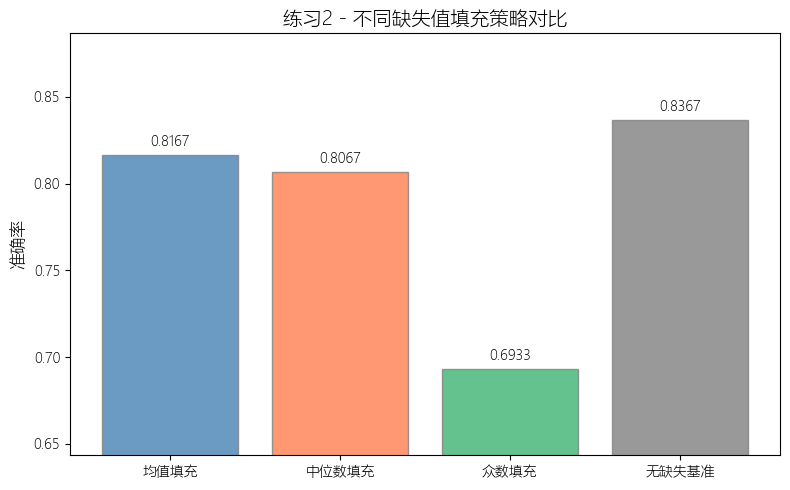

In [32]:
print("练习2：不同缺失值填充策略对比")
from sklearn.impute import SimpleImputer
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                           n_redundant=5, random_state=42)

# 随机插入缺失值（15%）
np.random.seed(42)
mask = np.random.rand(*X.shape) < 0.15
X_missing = X.copy()
X_missing[mask] = np.nan

print(f"\n总缺失值数量: {np.sum(mask)} ({np.sum(mask)/X.size*100:.1f}%)")

X_train, X_test, y_train, y_test = train_test_split(X_missing, y, test_size=0.3, random_state=42)

strategies = ['mean', 'median', 'most_frequent']
strategy_results = {}

for strategy in strategies:
    imputer = SimpleImputer(strategy=strategy)
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    # 标准化
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_imp)
    X_test_s = scaler.transform(X_test_imp)

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_s, y_train)
    acc = model.score(X_test_s, y_test)
    strategy_results[strategy] = acc

    cn_names = {'mean': '均值', 'median': '中位数', 'most_frequent': '众数'}
    print(f"填充策略: {strategy}({cn_names[strategy]}), 准确率: {acc:.4f}")

# 同时对比无缺失值的基准
scaler_base = StandardScaler()
X_train_base = scaler_base.fit_transform(X_train)  # 这里X_train有缺失值所以用原始无缺失数据重新划分
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.3, random_state=42)
scaler_base = StandardScaler()
X_train_b = scaler_base.fit_transform(X_train_orig)
X_test_b = scaler_base.transform(X_test_orig)
model_base = LogisticRegression(max_iter=1000, random_state=42)
model_base.fit(X_train_b, y_train_orig)
acc_base = model_base.score(X_test_b, y_test_orig)
strategy_results['无缺失值基准'] = acc_base
print(f"无缺失值基准准确率: {acc_base:.4f}")

# 可视化
fig, ax = plt.subplots(figsize=(8, 5))
names = ['均值填充', '中位数填充', '众数填充', '无缺失基准']
vals = [strategy_results['mean'], strategy_results['median'],
        strategy_results['most_frequent'], strategy_results['无缺失值基准']]
colors = ['steelblue', 'coral', 'mediumseagreen', 'gray']
bars = ax.bar(names, vals, color=colors, alpha=0.8, edgecolor='gray')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('练习2 - 不同缺失值填充策略对比', fontsize=14)
ax.set_ylabel('准确率', fontsize=12)
ax.set_ylim(min(vals) - 0.05, max(vals) + 0.05)
plt.tight_layout()
plt.show()

练习3：RFE递归特征消除 - 特征数与模型性能
  选取 2 个特征, 准确率: 0.7667
  选取 3 个特征, 准确率: 0.7800
  选取 4 个特征, 准确率: 0.7733
  选取 5 个特征, 准确率: 0.8167
  选取 6 个特征, 准确率: 0.8233
  选取 7 个特征, 准确率: 0.8333
  选取 8 个特征, 准确率: 0.8400
  选取 9 个特征, 准确率: 0.8433
  选取 10 个特征, 准确率: 0.8367
  选取 11 个特征, 准确率: 0.8333
  选取 12 个特征, 准确率: 0.8333
  选取 13 个特征, 准确率: 0.8333
  选取 14 个特征, 准确率: 0.8367
  选取 15 个特征, 准确率: 0.8367
  选取 16 个特征, 准确率: 0.8400
  选取 17 个特征, 准确率: 0.8400
  选取 18 个特征, 准确率: 0.8400
  选取 19 个特征, 准确率: 0.8400
  选取 20 个特征, 准确率: 0.8367

最佳特征数: 9, 最高准确率: 0.8433


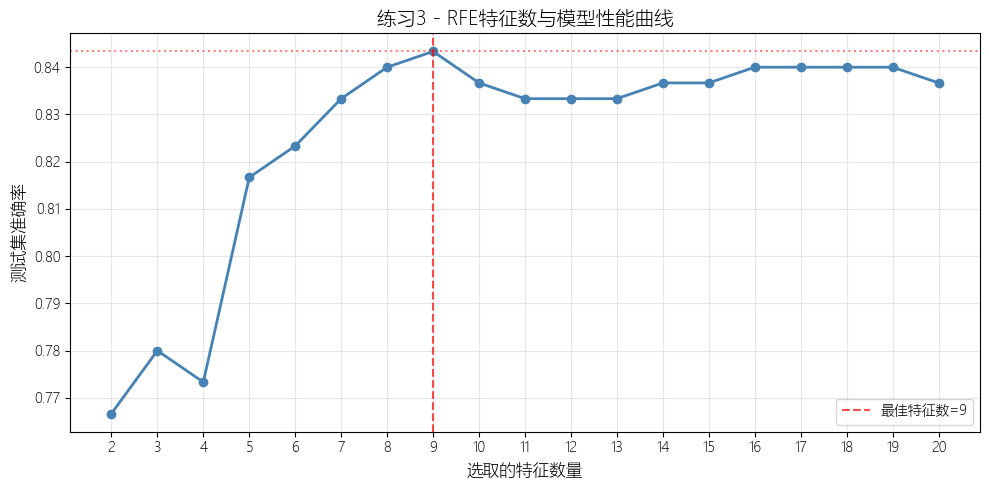

In [34]:
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, roc_curve, auc,
                            precision_score, recall_score, f1_score)
print("练习3：RFE递归特征消除 - 特征数与模型性能")
print("=" * 60)

X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                           n_redundant=5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

n_features_range = range(2, 21)
rfe_scores = []

for n in n_features_range:
    estimator = LogisticRegression(max_iter=1000, random_state=42)
    rfe = RFE(estimator=estimator, n_features_to_select=n, step=1)
    rfe.fit(X_train_s, y_train)
    X_test_rfe = rfe.transform(X_test_s)
    acc = accuracy_score(y_test, rfe.estimator_.predict(X_test_rfe))
    rfe_scores.append(acc)
    print(f"  选取 {n} 个特征, 准确率: {acc:.4f}")

best_n = list(n_features_range)[np.argmax(rfe_scores)]
print(f"\n最佳特征数: {best_n}, 最高准确率: {max(rfe_scores):.4f}")

# 可视化
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(n_features_range), rfe_scores, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.axvline(x=best_n, color='red', linestyle='--', alpha=0.7, label=f'最佳特征数={best_n}')
ax.axhline(y=max(rfe_scores), color='red', linestyle=':', alpha=0.5)
ax.set_title('练习3 - RFE特征数与模型性能曲线', fontsize=14)
ax.set_xlabel('选取的特征数量', fontsize=12)
ax.set_ylabel('测试集准确率', fontsize=12)
ax.set_xticks(list(n_features_range))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A: 1. 右偏分布（正偏态）的特征是尾部向右延伸，均值被极端大值拉高。
      例如：收入分布、网页访问量等都是典型的右偏分布。

   2. 对数变换 log(x) 的数学特性：
      - 对大值的压缩效果远强于小值。例如 log(1000)=6.9, log(10)=2.3, log(1)=0
      - 这恰好"拉回了"右尾的极端大值，使分布更对称

   3. 从几何角度：
      - 对数变换将乘法关系变为加法关系
      - 将指数增长变为线性增长
      - 使原本跨度巨大的数值范围被压缩到更窄的区间

   4. 对模型的好处：
      - 使特征分布更接近正态，满足很多模型（如线性回归、逻辑回归）的假设
      - 减少极端值（离群点）的影响
      - 线性模型更容易捕捉特征与目标之间的线性关系
      - 提升模型训练的稳定性和收敛速度

   5. 注意事项：
      - 数据必须为正数（或加1后取对数 log(x+1)）
      - 对数变换是不可逆的解释——变换后的系数含义会改变

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 49 篇：决策树 — 直观易懂的分类器**
>
> 下篇学决策树——一种直观易懂的机器学习算法，就像 if-else 的自动化版本，而且可视化效果超棒。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*